# Machine Learning-Based Mobile Money Fraud Detection

## An Experimental Study Using the PaySim Dataset

Group Members:
1. ##### Name: BAFFOUR ABRAHAM AWUAH | Index Number: UEB3512623 | GitHub: https://github.com/awuah-baffour

2. ##### Name: ABDUL WAKIL MAGIWABA DI-ELUMA | Index Number: UEB3502723| GitHub: https://github.com/mawdieluma-design

3. ##### Name: SARBAH DANIEL| Index Number: UEB3512723 | GitHub: https://github.com/Sarbah08


## Project Overview

Mobile-money fraud involves unauthorized or deceptive financial transactions carried out through mobile payment systems. Fraud detection is important because missed fraud can create direct financial loss, while excessive false alarms can inconvenience legitimate customers and reduce trust in the service.

Machine learning can help by learning transaction patterns associated with fraudulent behavior and assigning a risk score to new transactions. This experiment uses the PaySim dataset because it provides labeled mobile-money-style transaction records suitable for supervised fraud classification. PaySim is a synthetic simulation dataset, not real Ghanaian mobile-money transaction data.

## Objectives

1. Analyze patterns associated with fraudulent transactions.
2. Perform exploratory data analysis.
3. Engineer meaningful transaction-level features.
4. Compare multiple machine-learning algorithms.
5. Tune the strongest models.
6. Evaluate the final model using fraud-sensitive metrics.
7. Analyze the limitations of the PaySim experimental environment.

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.stats import randint, uniform

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    make_scorer,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
FINAL_THRESHOLD = 0.55

In [2]:
current_dir = Path.cwd().resolve()

if (current_dir / "paysim_100k.csv").exists():
    PROJECT_ROOT = current_dir
elif current_dir.name.lower() == "notebooks" and (current_dir.parent / "paysim_100k.csv").exists():
    PROJECT_ROOT = current_dir.parent
elif (current_dir.parent / "paysim_100k.csv").exists():
    PROJECT_ROOT = current_dir.parent
else:
    raise FileNotFoundError("Could not locate paysim_100k.csv using a relative project path.")

DATA_PATH = PROJECT_ROOT / "paysim_100k.csv"
FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"

FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATA_PATH)

Project root: C:\Users\DELL\Desktop\AI
Dataset: C:\Users\DELL\Desktop\AI\paysim_100k.csv


In [3]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (100000, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,352,CASH_OUT,352284.26,C350140872,105286.0,0.00,C902940189,0.00,352284.26,0,0
1,522,PAYMENT,31095.61,C1973708211,0.0,0.00,M559523006,0.00,0.00,0,0
2,154,TRANSFER,3493471.66,C1418190729,0.0,0.00,C441171330,12563216.68,16056688.34,0,0
3,346,CASH_OUT,171921.18,C792702322,0.0,0.00,C1316273086,371645.39,543566.56,0,0
4,332,PAYMENT,8611.65,C117067443,23563.0,14951.35,M1157793059,0.00,0.00,0,0


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types and non-null counts:")
df.info()

display(df.describe(include="all"))

Shape: (100000, 11)

Columns:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            100000 non-null  int64  
 1   type            100000 non-null  str    
 2   amount          100000 non-null  float64
 3   nameOrig        100000 non-null  str    
 4   oldbalanceOrg   100000 non-null  float64
 5   newbalanceOrig  100000 non-null  float64
 6   nameDest        100000 non-null  str    
 7   oldbalanceDest  100000 non-null  float64
 8   newbalanceDest  100000 non-null  float64
 9   isFraud         100000 non-null  int64  
 10  isFlaggedFraud  100000 non-null  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 8.4 MB


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,100000.000000,100000,1.000000e+05,100000,1.000000e+05,1.000000e+05,100000,1.000000e+05,1.000000e+05,100000.000000,100000.0000
unique,NaN,5,NaN,99999,NaN,NaN,92971,NaN,NaN,NaN,NaN
top,NaN,CASH_OUT,NaN,C649046785,NaN,NaN,C453211571,NaN,NaN,NaN,NaN
freq,NaN,35858,NaN,2,NaN,NaN,5,NaN,NaN,NaN,NaN
mean,249.805160,NaN,2.471184e+05,NaN,8.582537e+05,8.049294e+05,NaN,1.071770e+06,1.231282e+06,0.050000,0.0001
std,149.829919,NaN,8.817125e+05,NaN,2.872979e+06,2.826216e+06,NaN,3.489164e+06,3.807189e+06,0.217946,0.0100
min,1.000000,NaN,0.000000e+00,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000,0.0000
25%,156.000000,NaN,1.416413e+04,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000,0.0000
50%,250.000000,NaN,8.241296e+04,NaN,1.765103e+04,0.000000e+00,NaN,1.074855e+05,2.039985e+05,0.000000,0.0000
75%,348.000000,NaN,2.242770e+05,NaN,1.421877e+05,1.239473e+05,NaN,9.034824e+05,1.114548e+06,0.000000,0.0000


The important PaySim columns are:

- `step`: simulated time step.
- `type`: transaction type.
- `amount`: transaction amount.
- `nameOrig` and `nameDest`: origin and destination customer identifiers.
- `oldbalanceOrg` and `newbalanceOrig`: origin account balances before and after the transaction.
- `oldbalanceDest` and `newbalanceDest`: destination account balances before and after the transaction.
- `isFraud`: target label, where 1 indicates fraud and 0 indicates a legitimate transaction.
- `isFlaggedFraud`: PaySim's existing rule-based flag, not the machine-learning target.

Target counts:
isFraud
0    95000
1     5000
Name: count, dtype: int64

Target percentages:
isFraud
0    95.0
1     5.0
Name: proportion, dtype: float64


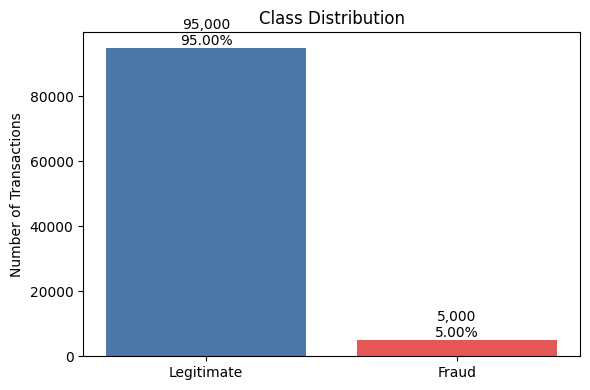

In [5]:
target_counts = df["isFraud"].value_counts().sort_index()
target_percentages = df["isFraud"].value_counts(normalize=True).sort_index() * 100

print("Target counts:")
print(target_counts)
print("\nTarget percentages:")
print(target_percentages.round(4))

fig, ax = plt.subplots(figsize=(6, 4))
labels = ["Legitimate", "Fraud"]
ax.bar(labels, target_counts.values, color=["#4C78A8", "#E45756"])
ax.set_title("Class Distribution")
ax.set_ylabel("Number of Transactions")
for i, value in enumerate(target_counts.values):
    ax.text(i, value, f"{value:,}\n{target_percentages.iloc[i]:.2f}%", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

In [6]:
expected_types = {"CASH_IN", "CASH_OUT", "DEBIT", "PAYMENT", "TRANSFER"}
balance_columns = ["oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]

quality_summary = {
    "Missing values": int(df.isnull().sum().sum()),
    "Duplicates": int(df.duplicated().sum()),
    "Negative amounts": int((df["amount"] < 0).sum()),
    "Negative balances": int((df[balance_columns] < 0).sum().sum()),
    "Unexpected transaction types": int((~df["type"].isin(expected_types)).sum()),
    "Unexpected target values": int((~df["isFraud"].isin([0, 1])).sum()),
}

for check, value in quality_summary.items():
    print(f"{check}: {value}")

print("\nMissing values by column:")
display(df.isnull().sum())

Missing values: 0
Duplicates: 0
Negative amounts: 0
Negative balances: 0
Unexpected transaction types: 0
Unexpected target values: 0

Missing values by column:


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

,transaction_count
type,
CASH_OUT,35858
PAYMENT,32379
CASH_IN,20745
TRANSFER,10396
DEBIT,622


isFraud,0,1
type,,
CASH_IN,20745,0
CASH_OUT,33310,2548
DEBIT,622,0
PAYMENT,32379,0
TRANSFER,7944,2452


,fraud_rate_percent
type,
TRANSFER,23.585995
CASH_OUT,7.105806
CASH_IN,0.000000
DEBIT,0.000000
PAYMENT,0.000000


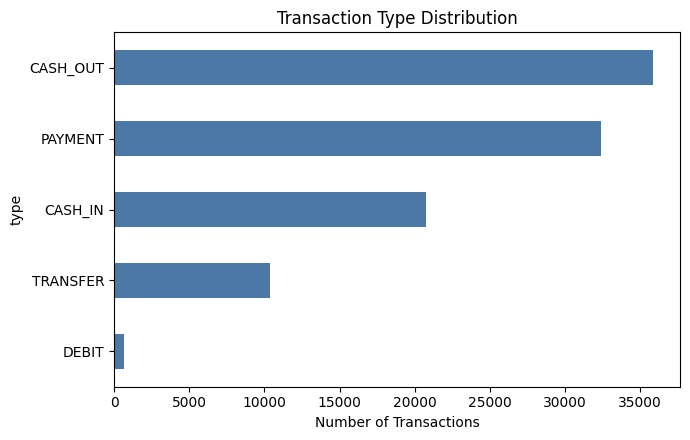

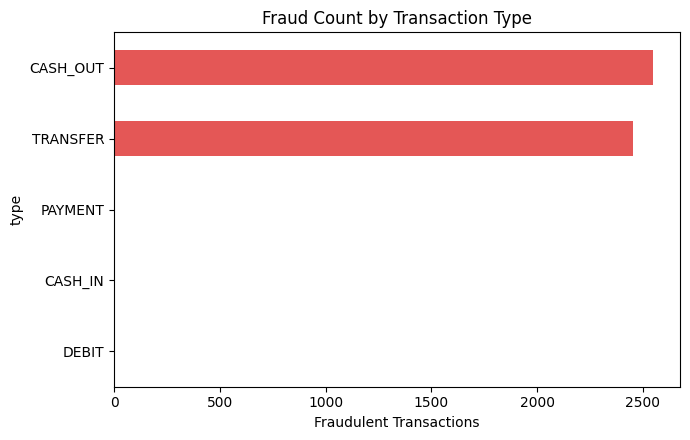

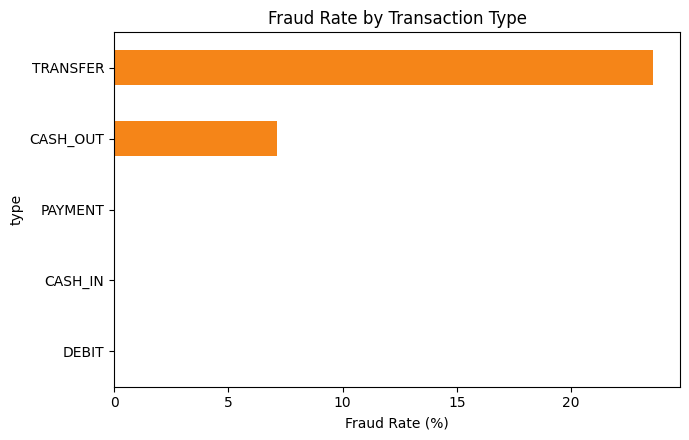

In [7]:
type_counts = df["type"].value_counts()
type_crosstab = pd.crosstab(df["type"], df["isFraud"])
fraud_rate_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False) * 100
fraud_count_by_type = df.groupby("type")["isFraud"].sum().sort_values(ascending=False)

display(type_counts.rename("transaction_count").to_frame())
display(type_crosstab)
display(fraud_rate_by_type.rename("fraud_rate_percent").to_frame())

fig, ax = plt.subplots(figsize=(7, 4.5))
type_counts.sort_values().plot(kind="barh", ax=ax, color="#4C78A8")
ax.set_title("Transaction Type Distribution")
ax.set_xlabel("Number of Transactions")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "transaction_type_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
fraud_count_by_type.sort_values().plot(kind="barh", ax=ax, color="#E45756")
ax.set_title("Fraud Count by Transaction Type")
ax.set_xlabel("Fraudulent Transactions")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fraud_by_transaction_type.png", dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
fraud_rate_by_type.sort_values().plot(kind="barh", ax=ax, color="#F58518")
ax.set_title("Fraud Rate by Transaction Type")
ax.set_xlabel("Fraud Rate (%)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fraud_rate_by_transaction_type.png", dpi=180, bbox_inches="tight")
plt.show()

,mean,median,max
isFraud,,,
Legitimate,1.803520e+05,74356.245,69886731.3
Fraud,1.515679e+06,450944.465,10000000.0


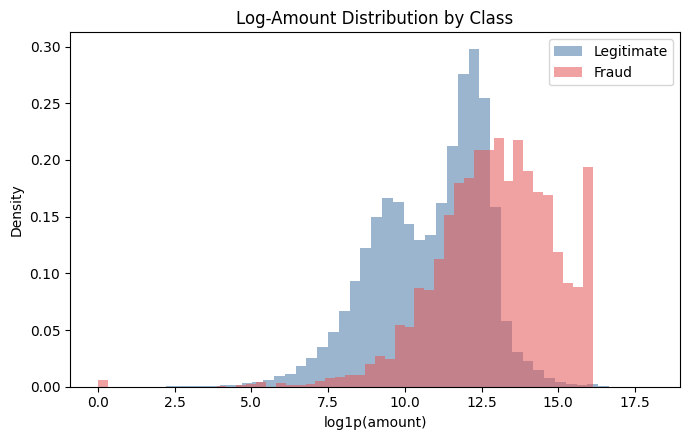

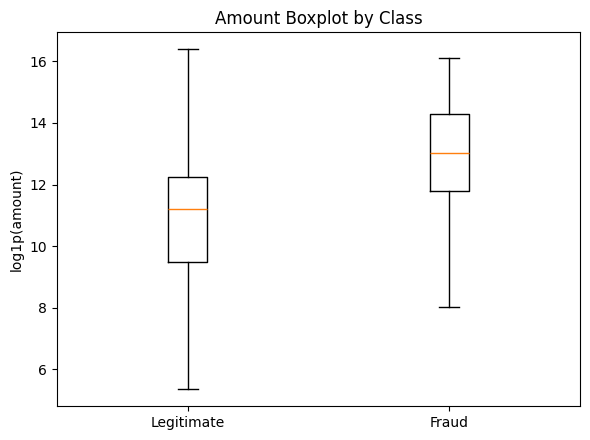

In [8]:
amount_summary = df.groupby("isFraud")["amount"].agg(["mean", "median", "max"]).rename(index={0: "Legitimate", 1: "Fraud"})
display(amount_summary)

fig, ax = plt.subplots(figsize=(7, 4.5))
for target_value, label, color in [(0, "Legitimate", "#4C78A8"), (1, "Fraud", "#E45756")]:
    values = np.log1p(df.loc[df["isFraud"] == target_value, "amount"])
    ax.hist(values, bins=50, alpha=0.55, label=label, color=color, density=True)
ax.set_title("Log-Amount Distribution by Class")
ax.set_xlabel("log1p(amount)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "amount_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.boxplot(
    [np.log1p(df.loc[df["isFraud"] == 0, "amount"]), np.log1p(df.loc[df["isFraud"] == 1, "amount"])],
    labels=["Legitimate", "Fraud"],
    showfliers=False,
)
ax.set_title("Amount Boxplot by Class")
ax.set_ylabel("log1p(amount)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "amount_boxplot.png", dpi=180, bbox_inches="tight")
plt.show()

oldbalanceOrg                          newbalanceOrig         \
                    mean      median          max           mean median   
isFraud                                                                   
Legitimate  8.137098e+05   13488.500  33474678.33  836698.144910    0.0   
Fraud       1.704586e+06  450259.575  57316255.05  201323.257182    0.0   

                        oldbalanceDest                           \
                    max           mean     median           max   
isFraud                                                           
Legitimate  33623300.06   1.097629e+06  131076.12  2.105993e+08   
Fraud       47316255.05   5.804587e+05       0.00  2.362305e+08   

           newbalanceDest                           
                     mean     median           max  
isFraud                                             
Legitimate   1.225253e+06  210780.50  2.214254e+08  
Fraud        1.345837e+06   23309.38  2.367265e+08

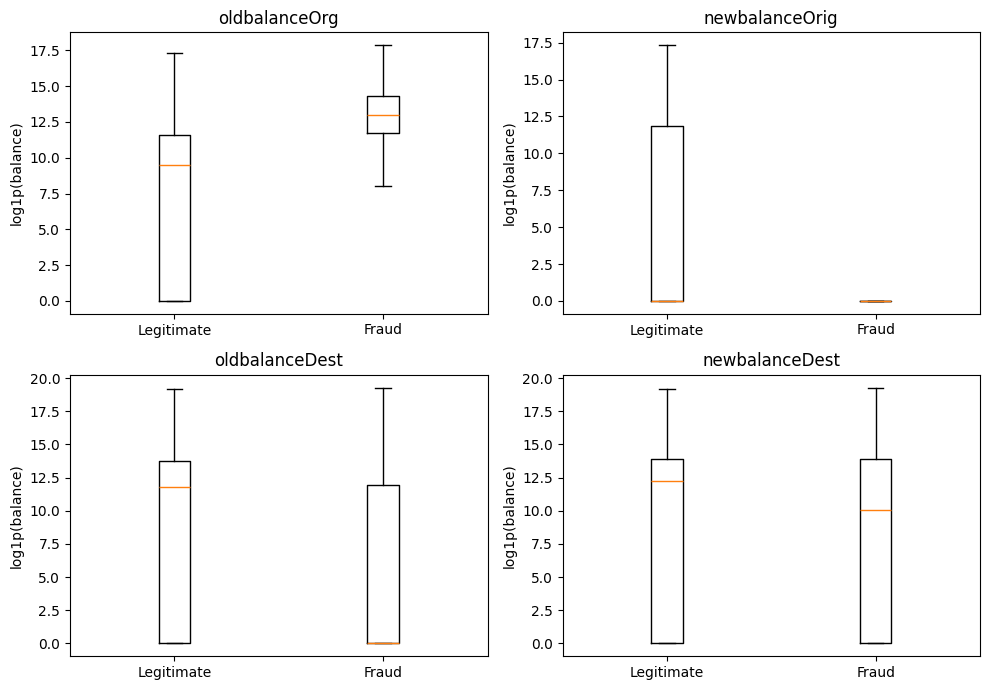

In [9]:
balance_columns = ["oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]
balance_summary = df.groupby("isFraud")[balance_columns].agg(["mean", "median", "max"]).rename(index={0: "Legitimate", 1: "Fraud"})
display(balance_summary)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.ravel()
for ax, column in zip(axes, balance_columns):
    data = [
        np.log1p(df.loc[df["isFraud"] == 0, column]),
        np.log1p(df.loc[df["isFraud"] == 1, column]),
    ]
    ax.boxplot(data, labels=["Legitimate", "Fraud"], showfliers=False)
    ax.set_title(column)
    ax.set_ylabel("log1p(balance)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "balance_analysis.png", dpi=180, bbox_inches="tight")
plt.show()

Post-transaction balance variables are useful for understanding the data, but they are excluded from the primary model. A fraud detector should normally score a transaction at or before authorization, so variables such as `newbalanceOrig` and `newbalanceDest` may contain information that would not be available at the intended prediction point.

origin_balance_change                          \
                            mean     median          max   
isFraud                                                    
Legitimate         -2.298830e+04       0.00   2802396.19   
Fraud               1.503263e+06  447531.94  10000000.00   

           destination_balance_change                         \
                                 mean    median          max   
isFraud                                                        
Legitimate              127624.073760     0.000  82704592.26   
Fraud                   765378.417184  4765.385  14915111.47   

           origin_balance_consistency_error                        \
                                       mean    median         max   
isFraud                                                             
Legitimate                    203340.335681  68869.79  69886731.3   
Fraud                          12416.260050      0.00  10000000.0   

           destination_balance_consistency_error                        
                                            mean   median          max  
isFraud                                                                 
Legitimate                          93933.139525  5151.24  56308418.91  
Fraud                              766219.545698  4591.07  10000000.00

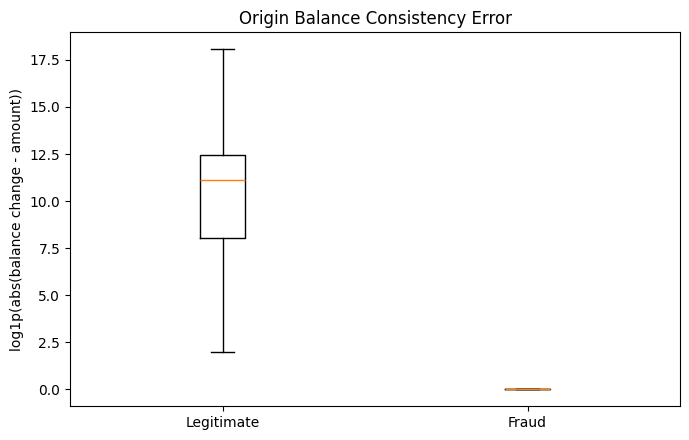

In [10]:
df["origin_balance_change"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["destination_balance_change"] = df["newbalanceDest"] - df["oldbalanceDest"]
df["origin_balance_consistency_error"] = (df["origin_balance_change"] - df["amount"]).abs()
df["destination_balance_consistency_error"] = (df["destination_balance_change"] - df["amount"]).abs()

consistency_summary = df.groupby("isFraud")[
    [
        "origin_balance_change",
        "destination_balance_change",
        "origin_balance_consistency_error",
        "destination_balance_consistency_error",
    ]
].agg(["mean", "median", "max"]).rename(index={0: "Legitimate", 1: "Fraud"})
display(consistency_summary)

fig, ax = plt.subplots(figsize=(7, 4.5))
errors = [
    np.log1p(df.loc[df["isFraud"] == 0, "origin_balance_consistency_error"]),
    np.log1p(df.loc[df["isFraud"] == 1, "origin_balance_consistency_error"]),
]
ax.boxplot(errors, labels=["Legitimate", "Fraud"], showfliers=False)
ax.set_title("Origin Balance Consistency Error")
ax.set_ylabel("log1p(abs(balance change - amount))")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "balance_consistency_errors.png", dpi=180, bbox_inches="tight")
plt.show()

,step,transactions,fraud_count,fraud_rate
0,1,53,7,0.132075
1,2,16,4,0.250000
2,3,11,3,0.272727
3,4,17,6,0.352941
4,5,14,3,0.214286


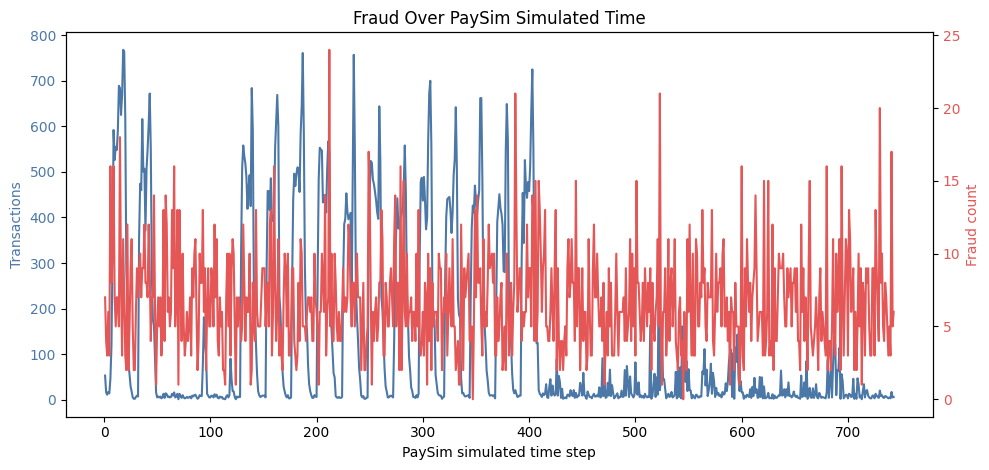

In [11]:
fraud_over_time = df.groupby("step").agg(
    transactions=("isFraud", "size"),
    fraud_count=("isFraud", "sum"),
    fraud_rate=("isFraud", "mean"),
).reset_index()

display(fraud_over_time.head())

fig, ax1 = plt.subplots(figsize=(10, 4.8))
ax1.plot(fraud_over_time["step"], fraud_over_time["transactions"], color="#4C78A8", label="Transactions")
ax1.set_xlabel("PaySim simulated time step")
ax1.set_ylabel("Transactions", color="#4C78A8")
ax1.tick_params(axis="y", labelcolor="#4C78A8")

ax2 = ax1.twinx()
ax2.plot(fraud_over_time["step"], fraud_over_time["fraud_count"], color="#E45756", label="Fraud count")
ax2.set_ylabel("Fraud count", color="#E45756")
ax2.tick_params(axis="y", labelcolor="#E45756")

ax1.set_title("Fraud Over PaySim Simulated Time")
fig.tight_layout()
plt.savefig(FIGURES_DIR / "fraud_over_time.png", dpi=180, bbox_inches="tight")
plt.show()

,step,amount,oldbalanceOrg,oldbalanceDest,origin_balance_change,destination_balance_change,isFraud
step,1.000000,0.083156,0.005480,0.016586,0.106408,0.030519,0.181073
amount,0.083156,1.000000,0.165514,0.202534,0.688932,0.764645,0.330073
oldbalanceOrg,0.005480,0.165514,1.000000,0.054317,0.184306,-0.008597,0.067582
oldbalanceDest,0.016586,0.202534,0.054317,1.000000,-0.027554,0.205394,-0.032304
origin_balance_change,0.106408,0.688932,0.184306,-0.027554,1.000000,0.338950,0.513917
destination_balance_change,0.030519,0.764645,-0.008597,0.205394,0.338950,1.000000,0.143769
isFraud,0.181073,0.330073,0.067582,-0.032304,0.513917,0.143769,1.000000


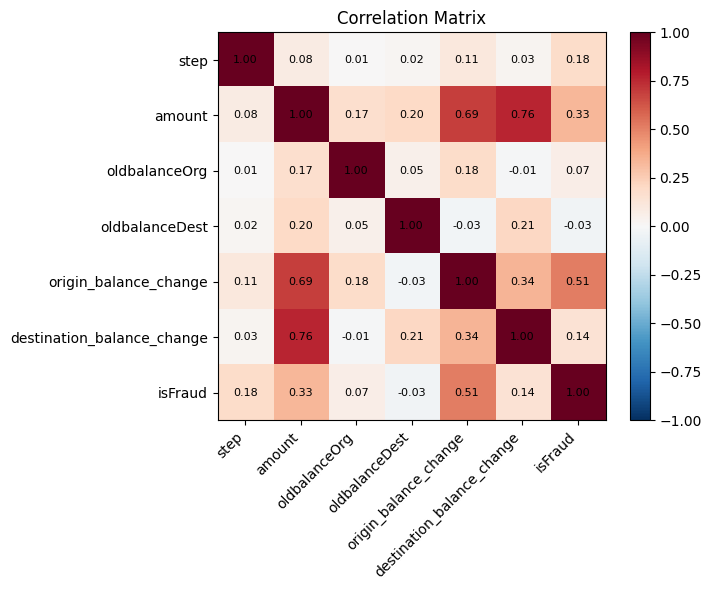

In [12]:
correlation_columns = [
    "step",
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "origin_balance_change",
    "destination_balance_change",
    "isFraud",
]
corr = df[correlation_columns].corr()
display(corr)

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

## Leakage Analysis

The primary model excludes several columns to reduce leakage and unrealistic prediction assumptions:

- `nameOrig` and `nameDest` are identifiers. They can encourage memorization rather than generalizable fraud detection.
- `isFlaggedFraud` is an existing PaySim rule indicator. Including it would mix a rule-based fraud flag into the model input.
- `newbalanceOrig` and `newbalanceDest` are post-transaction balances. These may contain information unavailable at the intended transaction-scoring point.
- `origin_balance_change` and `destination_balance_change` are derived from post-transaction balances, so they inherit the same leakage concern.

The resulting primary feature set focuses on transaction-time information and engineered variables that do not require post-transaction balances.

In [13]:
df["log_amount"] = np.log1p(df["amount"])
df["amount_to_origin_balance_ratio"] = df["amount"] / (df["oldbalanceOrg"] + 1.0)
df["amount_to_destination_balance_ratio"] = df["amount"] / (df["oldbalanceDest"] + 1.0)
df["origin_balance_zero"] = (df["oldbalanceOrg"] == 0).astype(int)
df["destination_balance_zero"] = (df["oldbalanceDest"] == 0).astype(int)
df["origin_balance_sufficient"] = (df["oldbalanceOrg"] >= df["amount"]).astype(int)
df["step_day"] = ((df["step"] - 1) // 24 + 1).astype(int)

engineered_features = [
    "log_amount",
    "amount_to_origin_balance_ratio",
    "amount_to_destination_balance_ratio",
    "origin_balance_zero",
    "destination_balance_zero",
    "origin_balance_sufficient",
    "step_day",
]

print("Engineered features created:")
print(engineered_features)
display(df[engineered_features].head())

Engineered features created:
['log_amount', 'amount_to_origin_balance_ratio', 'amount_to_destination_balance_ratio', 'origin_balance_zero', 'destination_balance_zero', 'origin_balance_sufficient', 'step_day']


,log_amount,amount_to_origin_balance_ratio,amount_to_destination_balance_ratio,origin_balance_zero,destination_balance_zero,origin_balance_sufficient,step_day
0,12.772197,3.345943e+00,352284.260000,0,1,0,15
1,10.344854,3.109561e+04,31095.610000,1,1,0,22
2,15.066407,3.493472e+06,0.278071,1,0,0,7
3,12.054797,1.719212e+05,0.462593,1,0,0,15
4,9.060987,3.654579e-01,8611.650000,0,1,1,14


In [14]:
FEATURES = [
    "step",
    "amount",
    "log_amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "amount_to_origin_balance_ratio",
    "amount_to_destination_balance_ratio",
    "origin_balance_zero",
    "destination_balance_zero",
    "origin_balance_sufficient",
    "step_day",
    "type",
]

X = df[FEATURES].copy()
y = df["isFraud"].copy()

forbidden_columns = {
    "isFraud",
    "nameOrig",
    "nameDest",
    "isFlaggedFraud",
    "newbalanceOrig",
    "newbalanceDest",
    "origin_balance_change",
    "destination_balance_change",
}
forbidden_present = sorted(forbidden_columns.intersection(X.columns))

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Forbidden columns present in X:", forbidden_present)
assert not forbidden_present
assert "isFraud" not in X.columns
display(X.head())

X shape: (100000, 12)
y shape: (100000,)
Forbidden columns present in X: []


,step,amount,log_amount,oldbalanceOrg,oldbalanceDest,amount_to_origin_balance_ratio,amount_to_destination_balance_ratio,origin_balance_zero,destination_balance_zero,origin_balance_sufficient,step_day,type
0,352,352284.26,12.772197,105286.0,0.00,3.345943e+00,352284.260000,0,1,0,15,CASH_OUT
1,522,31095.61,10.344854,0.0,0.00,3.109561e+04,31095.610000,1,1,0,22,PAYMENT
2,154,3493471.66,15.066407,0.0,12563216.68,3.493472e+06,0.278071,1,0,0,7,TRANSFER
3,346,171921.18,12.054797,0.0,371645.39,1.719212e+05,0.462593,1,0,0,15,CASH_OUT
4,332,8611.65,9.060987,23563.0,0.00,3.654579e-01,8611.650000,0,1,1,14,PAYMENT


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class distribution:")
print(y_train.value_counts().sort_index())
print("\nTest class distribution:")
print(y_test.value_counts().sort_index())

Train shape: (80000, 12)
Test shape: (20000, 12)

Train class distribution:
isFraud
0    76000
1     4000
Name: count, dtype: int64

Test class distribution:
isFraud
0    19000
1     1000
Name: count, dtype: int64


In [16]:
numeric_features = [
    "step",
    "amount",
    "log_amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "amount_to_origin_balance_ratio",
    "amount_to_destination_balance_ratio",
    "origin_balance_zero",
    "destination_balance_zero",
    "origin_balance_sufficient",
    "step_day",
]

categorical_features = ["type"]

try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", one_hot_encoder),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['step', 'amount', 'log_amount',
                                  'oldbalanceOrg', 'oldbalanceDest',
                                  'amount_to_origin_balance_ratio',
                                  'amount_to_destination_balance_ratio',
                                  'origin_balance_zero',
                                  'destination_balance_zero',
                                  'origin_balance_sufficient', 'step_day']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
        

In [17]:
def make_pipeline(classifier):
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", classifier),
        ]
    )

def evaluate_model(model_name, y_true, y_probability, threshold=0.50):
    y_pred = (y_probability >= threshold).astype(int)
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_probability),
        "PR-AUC": average_precision_score(y_true, y_probability),
    }

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

baseline_models = {}
baseline_probabilities = {}
baseline_predictions = {}
baseline_results = []

logistic_pipeline = make_pipeline(
    LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        solver="lbfgs",
        random_state=RANDOM_STATE,
    )
)

logistic_pipeline.fit(X_train, y_train)
logistic_probabilities = logistic_pipeline.predict_proba(X_test)[:, 1]
logistic_predictions = (logistic_probabilities >= 0.50).astype(int)

baseline_models["Logistic Regression"] = logistic_pipeline
baseline_probabilities["Logistic Regression"] = logistic_probabilities
baseline_predictions["Logistic Regression"] = logistic_predictions
baseline_results.append(evaluate_model("Logistic Regression", y_test, logistic_probabilities))

display(pd.DataFrame([baseline_results[-1]]))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.9583,0.545655,0.992,0.704045,0.993674,0.934935


In [18]:
random_forest_pipeline = make_pipeline(
    RandomForestClassifier(
        n_estimators=150,
        max_depth=18,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
)

random_forest_pipeline.fit(X_train, y_train)
random_forest_probabilities = random_forest_pipeline.predict_proba(X_test)[:, 1]
random_forest_predictions = (random_forest_probabilities >= 0.50).astype(int)

baseline_models["Random Forest"] = random_forest_pipeline
baseline_probabilities["Random Forest"] = random_forest_probabilities
baseline_predictions["Random Forest"] = random_forest_predictions
baseline_results.append(evaluate_model("Random Forest", y_test, random_forest_probabilities))

display(pd.DataFrame([baseline_results[-1]]))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest,0.99565,0.924651,0.994,0.958072,0.997621,0.99354


In [19]:
xgboost_pipeline = make_pipeline(
    XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.10,
        subsample=0.90,
        colsample_bytree=0.90,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
)

xgboost_pipeline.fit(X_train, y_train)
xgboost_probabilities = xgboost_pipeline.predict_proba(X_test)[:, 1]
xgboost_predictions = (xgboost_probabilities >= 0.50).astype(int)

baseline_models["XGBoost"] = xgboost_pipeline
baseline_probabilities["XGBoost"] = xgboost_probabilities
baseline_predictions["XGBoost"] = xgboost_predictions
baseline_results.append(evaluate_model("XGBoost", y_test, xgboost_probabilities))

display(pd.DataFrame([baseline_results[-1]]))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,XGBoost,0.9996,0.997992,0.994,0.995992,0.998848,0.99593


In [20]:
baseline_comparison = pd.DataFrame(baseline_results)[
    ["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
]
display(baseline_comparison.sort_values(["PR-AUC", "F1"], ascending=False))
baseline_comparison.to_csv(RESULTS_DIR / "notebook_baseline_model_comparison.csv", index=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
2,XGBoost,0.99960,0.997992,0.994,0.995992,0.998848,0.995930
1,Random Forest,0.99565,0.924651,0.994,0.958072,0.997621,0.993540
0,Logistic Regression,0.95830,0.545655,0.992,0.704045,0.993674,0.934935


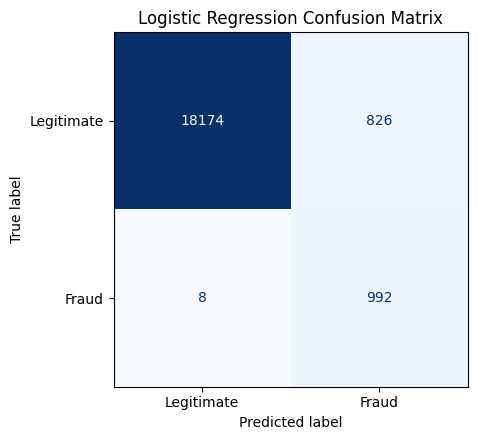

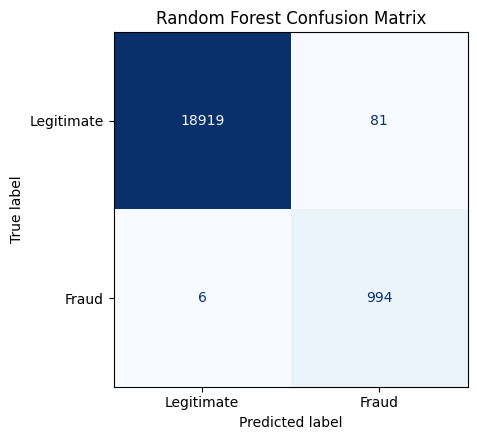

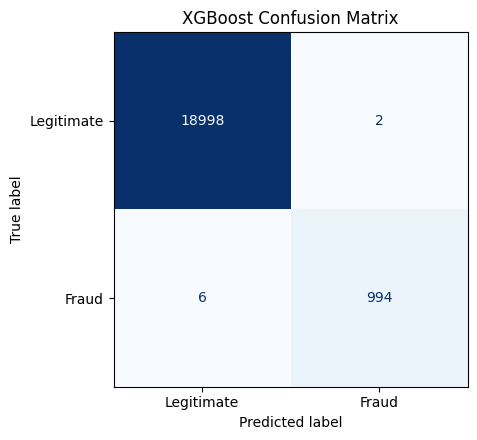

In [21]:
for model_name, predictions in baseline_predictions.items():
    matrix = confusion_matrix(y_test, predictions)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["Legitimate", "Fraud"],
    )
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    safe_name = model_name.lower().replace(" ", "_")
    plt.savefig(FIGURES_DIR / f"{safe_name}_confusion_matrix_from_notebook.png", dpi=180, bbox_inches="tight")
    plt.show()

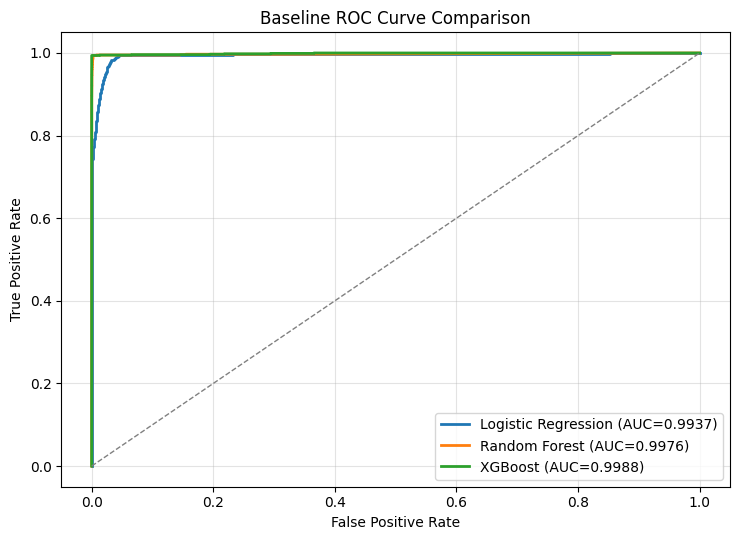

In [22]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for model_name, probabilities in baseline_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    auc_value = roc_auc_score(y_test, probabilities)
    ax.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC={auc_value:.4f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
ax.set_title("Baseline ROC Curve Comparison")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.grid(True, alpha=0.35)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "notebook_baseline_roc.png", dpi=180, bbox_inches="tight")
plt.show()

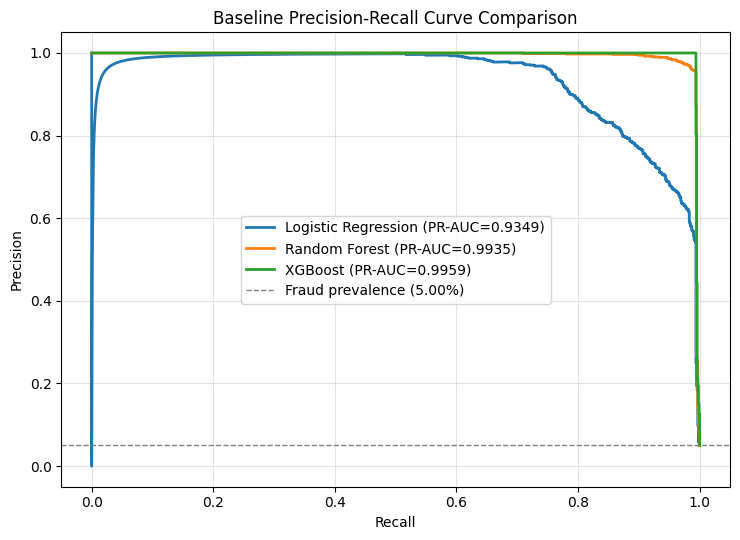

In [23]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for model_name, probabilities in baseline_probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test, probabilities)
    pr_auc = average_precision_score(y_test, probabilities)
    ax.plot(recall, precision, linewidth=2, label=f"{model_name} (PR-AUC={pr_auc:.4f})")
ax.axhline(y_train.mean(), linestyle="--", color="gray", linewidth=1, label=f"Fraud prevalence ({y_train.mean():.2%})")
ax.set_title("Baseline Precision-Recall Curve Comparison")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.grid(True, alpha=0.35)
ax.legend(loc="best")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "notebook_baseline_pr.png", dpi=180, bbox_inches="tight")
plt.show()

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "ROC-AUC": "roc_auc",
    "PR-AUC": "average_precision",
    "F1": "f1",
    "Precision": make_scorer(precision_score, zero_division=0),
    "Recall": "recall",
}

cv_rows = []
for model_name, model in baseline_models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
    )
    row = {"Model": model_name}
    for metric in scoring:
        row[f"{metric} Mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric} Std"] = scores[f"test_{metric}"].std()
    cv_rows.append(row)

baseline_cv_results = pd.DataFrame(cv_rows)
display(baseline_cv_results)
baseline_cv_results.to_csv(RESULTS_DIR / "notebook_baseline_cross_validation_results.csv", index=False)

,Model,ROC-AUC Mean,ROC-AUC Std,PR-AUC Mean,PR-AUC Std,F1 Mean,F1 Std,Precision Mean,Precision Std,Recall Mean,Recall Std
0,Logistic Regression,0.996049,0.000167,0.941684,0.005351,0.713425,0.003718,0.556556,0.004935,0.9935,0.001837
1,Random Forest,0.999730,0.000145,0.996688,0.001028,0.961898,0.002400,0.929199,0.004867,0.9970,0.001000
2,XGBoost,0.999764,0.000242,0.998805,0.000879,0.996252,0.001578,0.996008,0.002539,0.9965,0.001837


In [25]:
def get_tuning_search_spaces(scale_pos_weight):
    return {
        "Logistic Regression": (
            make_pipeline(
                LogisticRegression(
                    solver="lbfgs",
                    max_iter=1200,
                    random_state=RANDOM_STATE,
                )
            ),
            {
                "classifier__C": [0.05, 0.1, 0.5, 1.0, 2.0, 5.0],
                "classifier__class_weight": ["balanced", None],
            },
            8,
        ),
        "Random Forest": (
            make_pipeline(
                RandomForestClassifier(
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                )
            ),
            {
                "classifier__n_estimators": [100, 150, 220],
                "classifier__max_depth": [10, 14, 18, None],
                "classifier__min_samples_split": [2, 5, 10],
                "classifier__min_samples_leaf": [1, 2, 4],
                "classifier__max_features": ["sqrt", "log2", None],
                "classifier__class_weight": ["balanced", "balanced_subsample"],
            },
            10,
        ),
        "XGBoost": (
            make_pipeline(
                XGBClassifier(
                    objective="binary:logistic",
                    eval_metric="logloss",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                )
            ),
            {
                "classifier__n_estimators": randint(120, 281),
                "classifier__max_depth": randint(3, 7),
                "classifier__learning_rate": uniform(0.04, 0.12),
                "classifier__subsample": uniform(0.75, 0.25),
                "classifier__colsample_bytree": uniform(0.75, 0.25),
                "classifier__min_child_weight": randint(1, 7),
                "classifier__gamma": uniform(0.0, 0.4),
                "classifier__reg_alpha": uniform(0.0, 0.4),
                "classifier__reg_lambda": uniform(0.8, 1.5),
                "classifier__scale_pos_weight": [
                    scale_pos_weight,
                    scale_pos_weight * 0.75,
                    scale_pos_weight * 1.25,
                ],
            },
            12,
        ),
    }

tuned_models = {}
tuned_probabilities = {}
tuned_best_params = {}
tuning_rows = []

for model_name, (pipeline, param_distributions, n_iter) in get_tuning_search_spaces(scale_pos_weight).items():
    print(f"Tuning {model_name}...")
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring="average_precision",
        n_jobs=-1,
        cv=cv,
        random_state=RANDOM_STATE,
        verbose=0,
        refit=True,
        return_train_score=False,
    )
    search.fit(X_train, y_train)
    tuned_models[model_name] = search.best_estimator_
    tuned_best_params[model_name] = search.best_params_
    tuned_probabilities[model_name] = search.best_estimator_.predict_proba(X_test)[:, 1]
    tuning_rows.append(
        {
            "Model": model_name,
            "Best PR-AUC CV Score": search.best_score_,
            "Best Parameters": search.best_params_,
        }
    )

tuning_summary = pd.DataFrame(tuning_rows)
display(tuning_summary)
pd.DataFrame(
    [{"Model": model, "Best Parameters": str(params)} for model, params in tuned_best_params.items()]
).to_csv(RESULTS_DIR / "notebook_tuned_best_hyperparameters.csv", index=False)

Tuning Logistic Regression...


Tuning Random Forest...


Tuning XGBoost...


,Model,Best PR-AUC CV Score,Best Parameters
0,Logistic Regression,0.950726,"{'classifier__class_weight': None, 'classifier..."
1,Random Forest,0.996930,"{'classifier__n_estimators': 150, 'classifier_..."
2,XGBoost,0.999016,{'classifier__colsample_bytree': 0.83918833167...


In [26]:
tuned_results = []
tuned_predictions = {}

for model_name, probabilities in tuned_probabilities.items():
    tuned_predictions[model_name] = (probabilities >= 0.50).astype(int)
    tuned_results.append(evaluate_model(model_name, y_test, probabilities, threshold=0.50))

tuned_comparison = pd.DataFrame(tuned_results)[
    ["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
]
display(tuned_comparison.sort_values(["PR-AUC", "F1"], ascending=False))
tuned_comparison.to_csv(RESULTS_DIR / "notebook_tuned_model_comparison.csv", index=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
2,XGBoost,0.99945,0.994995,0.994,0.994497,0.999038,0.996299
1,Random Forest,0.99670,0.943074,0.994,0.967868,0.997474,0.993460
0,Logistic Regression,0.98710,0.897216,0.838,0.866598,0.993786,0.942226


,Threshold,Precision,Recall,F1,False Positive Rate,False Negative Rate,FP,FN,TP,TN
0,0.10,0.976447,0.995,0.985636,0.001263,0.005,24,5,995,18976
1,0.15,0.983185,0.994,0.988563,0.000895,0.006,17,6,994,18983
2,0.20,0.990040,0.994,0.992016,0.000526,0.006,10,6,994,18990
3,0.25,0.990040,0.994,0.992016,0.000526,0.006,10,6,994,18990
4,0.30,0.991027,0.994,0.992511,0.000474,0.006,9,6,994,18991
5,0.35,0.992016,0.994,0.993007,0.000421,0.006,8,6,994,18992
6,0.40,0.994000,0.994,0.994000,0.000316,0.006,6,6,994,18994
7,0.45,0.994995,0.994,0.994497,0.000263,0.006,5,6,994,18995
8,0.50,0.994995,0.994,0.994497,0.000263,0.006,5,6,994,18995
9,0.55,0.994995,0.994,0.994497,0.000263,0.006,5,6,994,18995


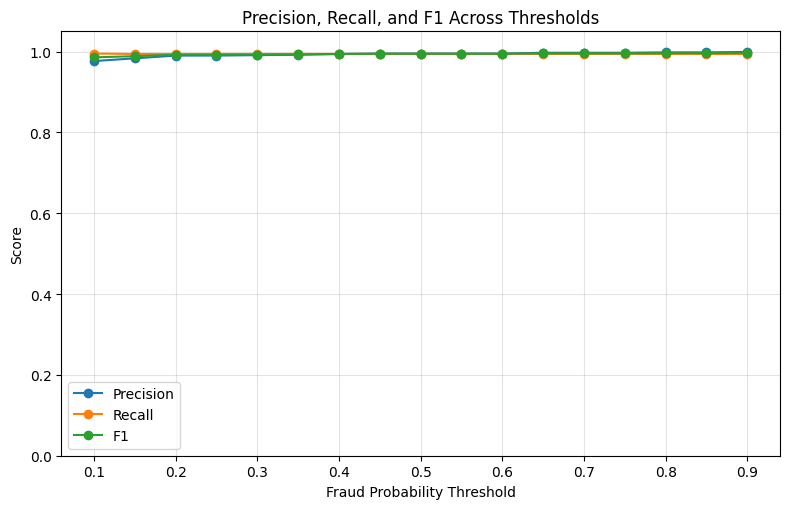

In [27]:
final_xgboost_model = tuned_models["XGBoost"]
final_probabilities = tuned_probabilities["XGBoost"]

thresholds = np.round(np.arange(0.10, 0.95, 0.05), 2)
threshold_rows = []

for threshold in thresholds:
    predictions = (final_probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()
    threshold_rows.append(
        {
            "Threshold": float(threshold),
            "Precision": precision_score(y_test, predictions, zero_division=0),
            "Recall": recall_score(y_test, predictions, zero_division=0),
            "F1": f1_score(y_test, predictions, zero_division=0),
            "False Positive Rate": fp / (fp + tn),
            "False Negative Rate": fn / (fn + tp),
            "FP": int(fp),
            "FN": int(fn),
            "TP": int(tp),
            "TN": int(tn),
        }
    )

threshold_analysis = pd.DataFrame(threshold_rows)
display(threshold_analysis)
threshold_analysis.to_csv(RESULTS_DIR / "threshold_analysis.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5.2))
ax.plot(threshold_analysis["Threshold"], threshold_analysis["Precision"], marker="o", label="Precision")
ax.plot(threshold_analysis["Threshold"], threshold_analysis["Recall"], marker="o", label="Recall")
ax.plot(threshold_analysis["Threshold"], threshold_analysis["F1"], marker="o", label="F1")
ax.set_title("Precision, Recall, and F1 Across Thresholds")
ax.set_xlabel("Fraud Probability Threshold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.35)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "precision_recall_vs_threshold.png", dpi=180, bbox_inches="tight")
plt.show()

In [28]:
FN_COST = 10
FP_COST = 1

threshold_analysis["Illustrative Cost"] = (
    threshold_analysis["FN"] * FN_COST + threshold_analysis["FP"] * FP_COST
)
display(threshold_analysis.sort_values(["Illustrative Cost", "Threshold"]).head(10))

cost_selected_threshold = threshold_analysis.sort_values(
    ["Illustrative Cost", "Recall", "Precision"],
    ascending=[True, False, False],
).iloc[0]["Threshold"]

selected_threshold = FINAL_THRESHOLD
print("Hypothetical academic teaching values:")
print(f"False negative cost = {FN_COST}")
print(f"False positive cost = {FP_COST}")
print(f"Lowest-cost threshold from this test-set illustration: {cost_selected_threshold:.2f}")
print(f"Established selected threshold used for final model: {selected_threshold:.2f}")

,Threshold,Precision,Recall,F1,False Positive Rate,False Negative Rate,FP,FN,TP,TN,Illustrative Cost
16,0.90,0.998995,0.994,0.996491,0.000053,0.006,1,6,994,18999,61
14,0.80,0.997992,0.994,0.995992,0.000105,0.006,2,6,994,18998,62
15,0.85,0.997992,0.994,0.995992,0.000105,0.006,2,6,994,18998,62
11,0.65,0.996991,0.994,0.995493,0.000158,0.006,3,6,994,18997,63
12,0.70,0.996991,0.994,0.995493,0.000158,0.006,3,6,994,18997,63
13,0.75,0.996991,0.994,0.995493,0.000158,0.006,3,6,994,18997,63
7,0.45,0.994995,0.994,0.994497,0.000263,0.006,5,6,994,18995,65
8,0.50,0.994995,0.994,0.994497,0.000263,0.006,5,6,994,18995,65
9,0.55,0.994995,0.994,0.994497,0.000263,0.006,5,6,994,18995,65
10,0.60,0.994995,0.994,0.994497,0.000263,0.006,5,6,994,18995,65


Hypothetical academic teaching values:
False negative cost = 10
False positive cost = 1
Lowest-cost threshold from this test-set illustration: 0.90
Established selected threshold used for final model: 0.55


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Threshold,TN,FP,FN,TP
0,XGBoost,0.99945,0.994995,0.994,0.994497,0.999038,0.996299,0.55,18995,5,6,994


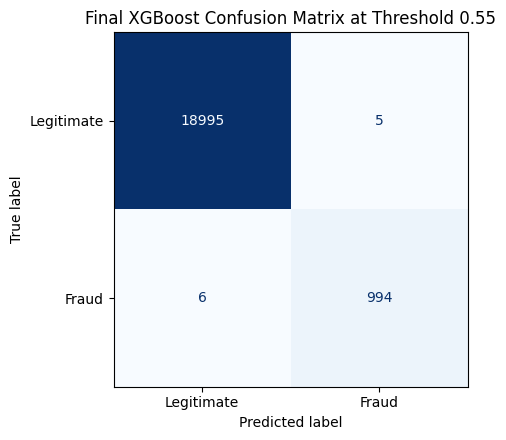

Expected confusion matrix: {'TN': 18995, 'FP': 5, 'FN': 6, 'TP': 994}
Reproduced confusion matrix: {'TN': 18995, 'FP': 5, 'FN': 6, 'TP': 994}


In [29]:
final_predictions = (final_probabilities >= selected_threshold).astype(int)
final_metrics = evaluate_model("XGBoost", y_test, final_probabilities, threshold=selected_threshold)
final_matrix = confusion_matrix(y_test, final_predictions)
tn, fp, fn, tp = final_matrix.ravel()

final_results = pd.DataFrame(
    [
        {
            **final_metrics,
            "Threshold": selected_threshold,
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
            "TP": int(tp),
        }
    ]
)
display(final_results)
final_results.to_csv(RESULTS_DIR / "stage5_final_test_metrics.csv", index=False)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(final_matrix, display_labels=["Legitimate", "Fraud"]).plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False,
)
ax.set_title(f"Final XGBoost Confusion Matrix at Threshold {selected_threshold:.2f}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "final_confusion_matrix_from_notebook.png", dpi=180, bbox_inches="tight")
plt.show()

expected = {"TN": 18995, "FP": 5, "FN": 6, "TP": 994}
reproduced = {"TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp)}
print("Expected confusion matrix:", expected)
print("Reproduced confusion matrix:", reproduced)
if reproduced != expected:
    print("The reproduced values differ from the established Stage 5 values. Check package versions, XGBoost determinism, and feature engineering details.")

,feature,importance
0,origin_balance_sufficient,0.424515
1,amount_to_origin_balance_ratio,0.209070
2,type_CASH_IN,0.155934
3,type_PAYMENT,0.086966
4,log_amount,0.021422
5,oldbalanceOrg,0.019647
6,amount_to_destination_balance_ratio,0.018786
7,amount,0.018262
8,type_TRANSFER,0.015197
9,origin_balance_zero,0.009412


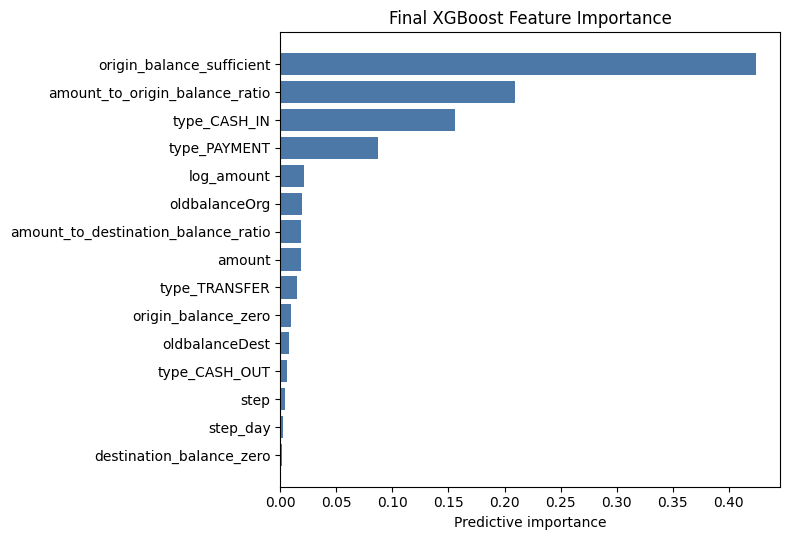

These are predictive importance values and should not be interpreted as causal explanations.


In [30]:
feature_names = final_xgboost_model.named_steps["preprocessor"].get_feature_names_out()
importances = final_xgboost_model.named_steps["classifier"].feature_importances_

feature_importance = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance.head(15))
feature_importance.to_csv(RESULTS_DIR / "stage5_final_feature_importance.csv", index=False)

top_features = feature_importance.head(15).sort_values("importance", ascending=True)
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top_features["feature"], top_features["importance"], color="#4C78A8")
ax.set_title("Final XGBoost Feature Importance")
ax.set_xlabel("Predictive importance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "final_feature_importance.png", dpi=180, bbox_inches="tight")
plt.show()

print("These are predictive importance values and should not be interpreted as causal explanations.")

,Precision,Recall,F1,TN,FP,FN,TP
0,0.108202,1.0,0.195274,10758,8242,0,1000


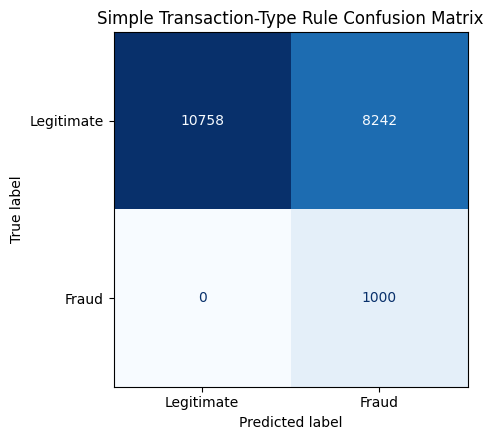

In [31]:
rule_prediction = X_test["type"].isin(["TRANSFER", "CASH_OUT"]).astype(int)
rule_matrix = confusion_matrix(y_test, rule_prediction)
rule_results = {
    "Precision": precision_score(y_test, rule_prediction, zero_division=0),
    "Recall": recall_score(y_test, rule_prediction, zero_division=0),
    "F1": f1_score(y_test, rule_prediction, zero_division=0),
    "TN": int(rule_matrix.ravel()[0]),
    "FP": int(rule_matrix.ravel()[1]),
    "FN": int(rule_matrix.ravel()[2]),
    "TP": int(rule_matrix.ravel()[3]),
}

display(pd.DataFrame([rule_results]))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(rule_matrix, display_labels=["Legitimate", "Fraud"]).plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False,
)
ax.set_title("Simple Transaction-Type Rule Confusion Matrix")
plt.tight_layout()
plt.show()

## Simple Transaction-Type Baseline Interpretation

The rule `type in ["TRANSFER", "CASH_OUT"]` is useful diagnostically because PaySim fraud is strongly associated with these transaction types. However, it is not sufficient as a final detector: it captures fraud very broadly but produces many false positives, so precision is much lower than the trained XGBoost model.

## Final Discussion

XGBoost performed best because boosted decision trees can model nonlinear relationships and interactions among amount, transaction type, balance sufficiency, and balance-ratio features. In fraud detection, precision and recall are both important: high recall reduces missed fraud, while high precision reduces unnecessary disruption to legitimate customers.

Threshold selection changes the operating behavior of the model. Lower thresholds usually increase recall but create more false positives, while higher thresholds usually improve precision at the risk of missing fraud. The selected threshold of 0.55 reflects the established experiment setting and the academic cost illustration used in this project.

The results are unusually high and should be discussed carefully. PaySim is synthetic, and the reduced dataset contains PaySim-specific transaction patterns that can make classification easier than real production fraud detection. These results cannot automatically be assumed to generalize to Ghanaian mobile-money systems because no real Ghanaian transaction data was used for external validation.

## Limitations

1. PaySim is synthetic.
2. Only 100,000 records were used.
3. The sample contains a controlled 5% fraud rate.
4. Fraud distribution may not reflect Ghanaian reality.
5. PaySim-specific patterns may make classification easier.
6. No real Ghanaian mobile-money transaction data was available.
7. The threshold cost assumptions are hypothetical.
8. External validation is required.

## Conclusion

The experiment demonstrates the feasibility of machine-learning-based fraud classification within the reduced PaySim environment. XGBoost was selected as the final model with an operating threshold of 0.55 because it achieved the strongest fraud-sensitive performance among the evaluated models.

The final model achieved approximately 0.99945 accuracy, 0.99499 precision, 0.99400 recall, 0.99450 F1, 0.99904 ROC-AUC, and 0.99630 PR-AUC in the established Stage 5 test evaluation. These results should not be interpreted as evidence of equivalent performance on real-world Ghanaian mobile-money transactions.